# 永久投资组合 · 中国市场版

**策略概览**（作者：栀染，来源：知乎）

基于哈利布朗永久组合理念，针对 A 股市场特性重新设计的多资产配置方案：

| 资产类别 | ETF | 代码 | 目标权重 | 逻辑 |
|---|---|---|---|---|
| 红利低波 | 华泰柏瑞红利低波ETF | 512890 | 25% | 防御性权益，A股少数夏普能看的资产 |
| 利率债 | 十年国债ETF | 511260 | 25% | 真正的 safe haven，股市崩盘时对冲 |
| 黄金 | 黄金ETF | 518880 | 20% | 对冲汇率风险和极端地缘风险 |
| QDII 美股 | 标普500ETF | 513500 | 30% | 引入低相关性资产，真正的多样化 |

回测区间 2024-01-01 ~ 最新（QQ Finance 可用窗口约 640 交易日），初始资金 100 万。
含交易成本（佣金万3 + 印花税千0.5），对比两版：无 QDII 限制 vs QDII 25% 硬顶（模拟实际申购限额，溢出部分按比例分配到其他三类资产）。

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from datetime import datetime
warnings.filterwarnings('ignore')

_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'risk_parity.py')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, _ROOT)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
print('Root:', _ROOT)

Root: /Users/riceball/Documents/Projs/fund


## 1. 数据获取

数据源降级顺序：QQ Finance → akshare → baostock

In [2]:
DATA_DIR = os.path.join(_ROOT, 'data')

ASSET_MAP = {
    '512890': '红利低波',
    '511260': '十年国债',
    '518880': '黄金',
    '513500': '标普500',
}
BENCH_MAP = {
    '000300': '沪深300',
    '000012': '中证全债',
}
ALL_CODES = {**ASSET_MAP, **BENCH_MAP}


def _std(df):
    rename = {
        '日期': 'date', '开盘': 'open', '最高': 'high',
        '最低': 'low', '收盘': 'close', '成交量': 'volume',
    }
    df = df.rename(columns=rename)
    cols = ['date', 'open', 'high', 'low', 'close', 'volume']
    df = df[[c for c in cols if c in df.columns]]
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df


def fetch_data(code, start_dt, end_dt):
    try:
        from data.sources import qq
        df = qq.fetch(code, start_dt, end_dt)
        if df is not None and not df.empty:
            return df
    except Exception as e:
        print(f'  [QQ {code}] {e}')
    try:
        import akshare as ak
        s, e = start_dt.strftime('%Y%m%d'), end_dt.strftime('%Y%m%d')
        df = ak.fund_etf_hist_em(symbol=code, period='daily',
                                  start_date=s, end_date=e, adjust='qfq')
        if df is not None and not df.empty:
            return _std(df)
    except Exception as e:
        print(f'  [akshare {code}] {e}')
    try:
        import akshare as ak
        s, e = start_dt.strftime('%Y%m%d'), end_dt.strftime('%Y%m%d')
        df = ak.index_zh_a_hist(symbol=code, period='daily',
                                start_date=s, end_date=e)
        if df is not None and not df.empty:
            return _std(df)
    except Exception as e:
        print(f'  [akshare idx {code}] {e}')
    return None


FETCH_START = datetime(2018, 1, 1)
FETCH_END = datetime(2026, 12, 31)
all_data: Dict[str, pd.DataFrame] = {}

for code, name in ALL_CODES.items():
    print(f'Fetching {code} ({name})...')
    df = fetch_data(code, FETCH_START, FETCH_END)
    if df is not None and len(df) > 0:
        all_data[code] = df
        print(f'  OK: {len(df)} rows, {df.index[0].date()} ~ {df.index[-1].date()}')
    else:
        print(f'  FAILED: no data for {code}')

print(f'\nLoaded {len(all_data)}/{len(ALL_CODES)} assets')
print('Available:', list(all_data.keys()))

Fetching 512890 (红利低波)...


  OK: 640 rows, 2023-12-29 ~ 2026-08-21
Fetching 511260 (十年国债)...
  OK: 640 rows, 2023-12-29 ~ 2026-08-21
Fetching 518880 (黄金)...


  OK: 640 rows, 2023-12-29 ~ 2026-08-21
Fetching 513500 (标普500)...
  OK: 640 rows, 2023-12-29 ~ 2026-08-21
Fetching 000300 (沪深300)...


  OK: 640 rows, 2023-12-29 ~ 2026-08-21
Fetching 000012 (中证全债)...


  OK: 640 rows, 2023-12-29 ~ 2026-08-21

Loaded 6/6 assets
Available: ['512890', '511260', '518880', '513500', '000300', '000012']


## 2. 参数定义

In [3]:
available_starts = {code: all_data[code].index[0] for code in ALL_CODES if code in all_data}
BT_START = max(available_starts.values()) if available_starts else pd.Timestamp('2024-01-01')
BT_END = pd.Timestamp.today().normalize()
INITIAL_CAPITAL = 1_000_000.0

TARGET_WEIGHTS = {
    '512890': 0.25,
    '511260': 0.25,
    '518880': 0.20,
    '513500': 0.30,
}

COMMISSION = 0.0003
STAMP_TAX = 0.0005

QDII_CODE = '513500'
QDII_CAP = 0.25

BENCH_6040_WEIGHTS = {
    '000300': 0.60,
    '511260': 0.40,
}

print(f'Backtest: {BT_START.date()} ~ {BT_END.date()}')
print(f'Initial capital: {INITIAL_CAPITAL:,.0f}')
print('Target weights:', TARGET_WEIGHTS)
print('60/40 weights:', BENCH_6040_WEIGHTS)
print(f'Costs: commission={COMMISSION:.4%} stamp_tax={STAMP_TAX:.4%}')
print(f'QDII cap: {QDII_CAP:.0%}')

Backtest: 2023-12-29 ~ 2026-08-22
Initial capital: 1,000,000
Target weights: {'512890': 0.25, '511260': 0.25, '518880': 0.2, '513500': 0.3}
60/40 weights: {'000300': 0.6, '511260': 0.4}
Costs: commission=0.0300% stamp_tax=0.0500%
QDII cap: 25%


In [4]:
def gen_quarterly_rebal(dates, start, end):
    days = sorted([d for d in dates if start <= d <= end])
    if not days:
        return []
    out, cur_q = [], None
    for d in days:
        q = (d.year, d.quarter)
        if q != cur_q:
            out.append(d)
            cur_q = q
    return out

all_days = sorted(set(d for df in all_data.values() for d in df.index))
all_days = [d for d in all_days if BT_START <= d]
rebal_dates = gen_quarterly_rebal(all_days, BT_START, BT_END)
print(f'Rebalance dates: {len(rebal_dates)}')
print([d.date() for d in rebal_dates])

Rebalance dates: 12
[datetime.date(2023, 12, 29), datetime.date(2024, 1, 2), datetime.date(2024, 4, 1), datetime.date(2024, 7, 1), datetime.date(2024, 10, 8), datetime.date(2025, 1, 2), datetime.date(2025, 4, 1), datetime.date(2025, 7, 1), datetime.date(2025, 10, 9), datetime.date(2026, 1, 5), datetime.date(2026, 4, 1), datetime.date(2026, 7, 1)]


## 3. 核心回测函数

In [5]:
@dataclass
class BTResult:
    daily_nav: pd.Series = field(default_factory=pd.Series)
    daily_weights: pd.DataFrame = field(default_factory=pd.DataFrame)
    quarterly_pos: pd.DataFrame = field(default_factory=pd.DataFrame)
    trades: List[dict] = field(default_factory=list)
    total_cost: float = 0.0


def run_backtest(all_data, target_w, rebal_dates,
                 init_cap=1e6, qdii_cap=None,
                 comm=0.0003, tax=0.0005):
    result = BTResult()
    all_dates = sorted(set(d for df in all_data.values() for d in df.index))
    all_dates = [d for d in all_dates if rebal_dates[0] <= d <= rebal_dates[-1]]
    rebal_set = set(rebal_dates)

    nav = init_cap
    shares: Dict[str, float] = {}
    cost_acc = 0.0
    nav_recs, w_recs, pos_recs, trades = [], [], [], []

    def gc(c, d):
        df = all_data.get(c)
        if df is not None and d in df.index:
            return float(df.loc[d, 'close'])
        return None

    def calc_nav(d):
        return sum(sh * (gc(c, d) or 0) for c, sh in shares.items())

    def apply_cap(w, cap):
        if cap is None or QDII_CODE not in w:
            return dict(w)
        w = dict(w)
        if w[QDII_CODE] <= cap:
            return w
        over = w[QDII_CODE] - cap
        w[QDII_CODE] = cap
        others = {c: v for c, v in w.items() if c != QDII_CODE and v > 0}
        s = sum(others.values())
        if s > 0:
            for c in others:
                w[c] += over * others[c] / s
        return w

    for day in all_dates:
        if day in rebal_set:
            nav = calc_nav(day)
            if nav <= 0:
                nav = init_cap
            tw = apply_cap(target_w, qdii_cap)
            tgt = {c: nav * v for c, v in tw.items() if v > 0}
            cur = {c: shares.get(c, 0) * (gc(c, day) or 0)
                   for c in shares if shares.get(c, 0) > 0}
            for c in list(shares):
                cv = cur.get(c, 0)
                tv = tgt.get(c, 0)
                if c not in tgt or tv < cv:
                    p = gc(c, day)
                    if p is None or p <= 0 or shares[c] <= 0:
                        continue
                    amt = cv - tv
                    if amt <= 0:
                        continue
                    sh = min(shares[c], amt / p)
                    proceeds = sh * p
                    cost = proceeds * (comm + tax)
                    cost_acc += cost
                    shares[c] -= sh
                    nav += proceeds - cost
                    trades.append({'date': day, 'code': c, 'action': 'sell',
                                   'shares': sh, 'price': p, 'amount': proceeds, 'cost': cost})
            shares = {c: s for c, s in shares.items() if s > 1e-8}
            cur2 = {c: shares.get(c, 0) * (gc(c, day) or 0)
                    for c in shares if shares.get(c, 0) > 0}
            for c, tv in tgt.items():
                cv2 = cur2.get(c, 0)
                if tv <= cv2:
                    continue
                p = gc(c, day)
                if p is None or p <= 0:
                    continue
                amt = tv - cv2
                cost = amt * comm
                cost_acc += cost
                shares[c] = shares.get(c, 0) + amt / p
                nav -= amt + cost
                trades.append({'date': day, 'code': c, 'action': 'buy',
                               'shares': amt / p, 'price': p, 'amount': amt, 'cost': cost})
            pos = {'date': day}
            for c in shares:
                p = gc(c, day)
                if p is not None:
                    pos[c] = shares[c] * p
            pos_recs.append(pos)
        tv = calc_nav(day)
        if tv > 0:
            nav_recs.append({'date': day, 'nav': tv})
            wr = {'date': day}
            for c in set(list(shares) + list(target_w)):
                p = gc(c, day)
                if p and c in shares and shares[c] > 0:
                    wr[c] = shares[c] * p / tv
                else:
                    wr[c] = 0.0
            w_recs.append(wr)

    if nav_recs:
        df = pd.DataFrame(nav_recs).set_index('date')
        result.daily_nav = df['nav'] / df['nav'].iloc[0]
    if w_recs:
        result.daily_weights = pd.DataFrame(w_recs).set_index('date')
    if pos_recs:
        result.quarterly_pos = pd.DataFrame(pos_recs).set_index('date')
    result.trades = trades
    result.total_cost = cost_acc
    return result

## 4. 运行回测

In [6]:
print('=== Version A: No QDII Cap ===')
bt_a = run_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                    init_cap=INITIAL_CAPITAL, qdii_cap=None,
                    comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_a.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_a.total_cost:,.0f}')
print(f'  Trades: {len(bt_a.trades)}')

print('\n=== Version B: QDII 30% Cap ===')
bt_b = run_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                    init_cap=INITIAL_CAPITAL, qdii_cap=QDII_CAP,
                    comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_b.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_b.total_cost:,.0f}')
print(f'  Trades: {len(bt_b.trades)}')

print('\n=== Benchmark: CSI300 Buy & Hold ===')
bench_300_nav = None
if '000300' in all_data:
    b300 = all_data['000300']
    b300 = b300[(b300.index >= BT_START) & (b300.index <= BT_END)]
    bench_300_nav = b300['close'] / b300['close'].iloc[0]
    print(f'  NAV end: {bench_300_nav.iloc[-1]:.4f}')
else:
    print('  No CSI300 data')

print('\n=== Benchmark: 60/40 Quarterly ===')
bt_6040 = run_backtest(all_data, BENCH_6040_WEIGHTS, rebal_dates,
                       init_cap=INITIAL_CAPITAL, qdii_cap=None,
                       comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_6040.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_6040.total_cost:,.0f}')

=== Version A: No QDII Cap ===
  NAV end: 1.4031
  Total cost: 667
  Trades: 51

=== Version B: QDII 30% Cap ===
  NAV end: 1.3899
  Total cost: 656
  Trades: 51

=== Benchmark: CSI300 Buy & Hold ===
  NAV end: 1.3462

=== Benchmark: 60/40 Quarterly ===
  NAV end: 1.3218
  Total cost: 549


## 5. 绩效摘要

In [7]:
def calc_perf(nav, name):
    ret = nav.pct_change().dropna()
    if len(ret) == 0:
        return {}
    ann_ret = (1+ret).prod() ** (252/len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.02) / ann_vol if ann_vol > 0 else 0
    dd = nav / nav.expanding().max() - 1
    mdd = dd.min()
    calmar = (ann_ret - 0.02) / abs(mdd) if mdd != 0 else 0
    downside = ret[ret < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) > 1 else 0
    sortino = (ann_ret - 0.02) / down_vol if down_vol > 0 else 0
    return {
        'name': name,
        'cumulative': nav.iloc[-1] - 1,
        'annual_return': ann_ret,
        'annual_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'calmar': calmar,
        'max_drawdown': mdd,
    }

results = []
results.append(calc_perf(bt_a.daily_nav, '永久组合A(无QDII限制)'))
results.append(calc_perf(bt_b.daily_nav, '永久组合B(QDII 30%顶)'))
if bench_300_nav is not None:
    results.append(calc_perf(bench_300_nav, '沪深300买入持有'))
results.append(calc_perf(bt_6040.daily_nav, '60/40组合'))

perf_df = pd.DataFrame(results).set_index('name')
print(perf_df.round(4).to_string())

                  cumulative  annual_return  annual_vol  sharpe  sortino  calmar  max_drawdown
name                                                                                          
永久组合A(无QDII限制)        0.4031         0.1523      0.0959  1.3800   1.5211  1.4106       -0.0938
永久组合B(QDII 30%顶)      0.3899         0.1478      0.0929  1.3745   1.5055  1.3816       -0.0925
沪深300买入持有             0.3462         0.1244      0.1884  0.5540   0.7834  0.6664       -0.1566
60/40组合               0.3218         0.1239      0.1080  0.9618   1.3888  1.3582       -0.0765


## 6. 可视化

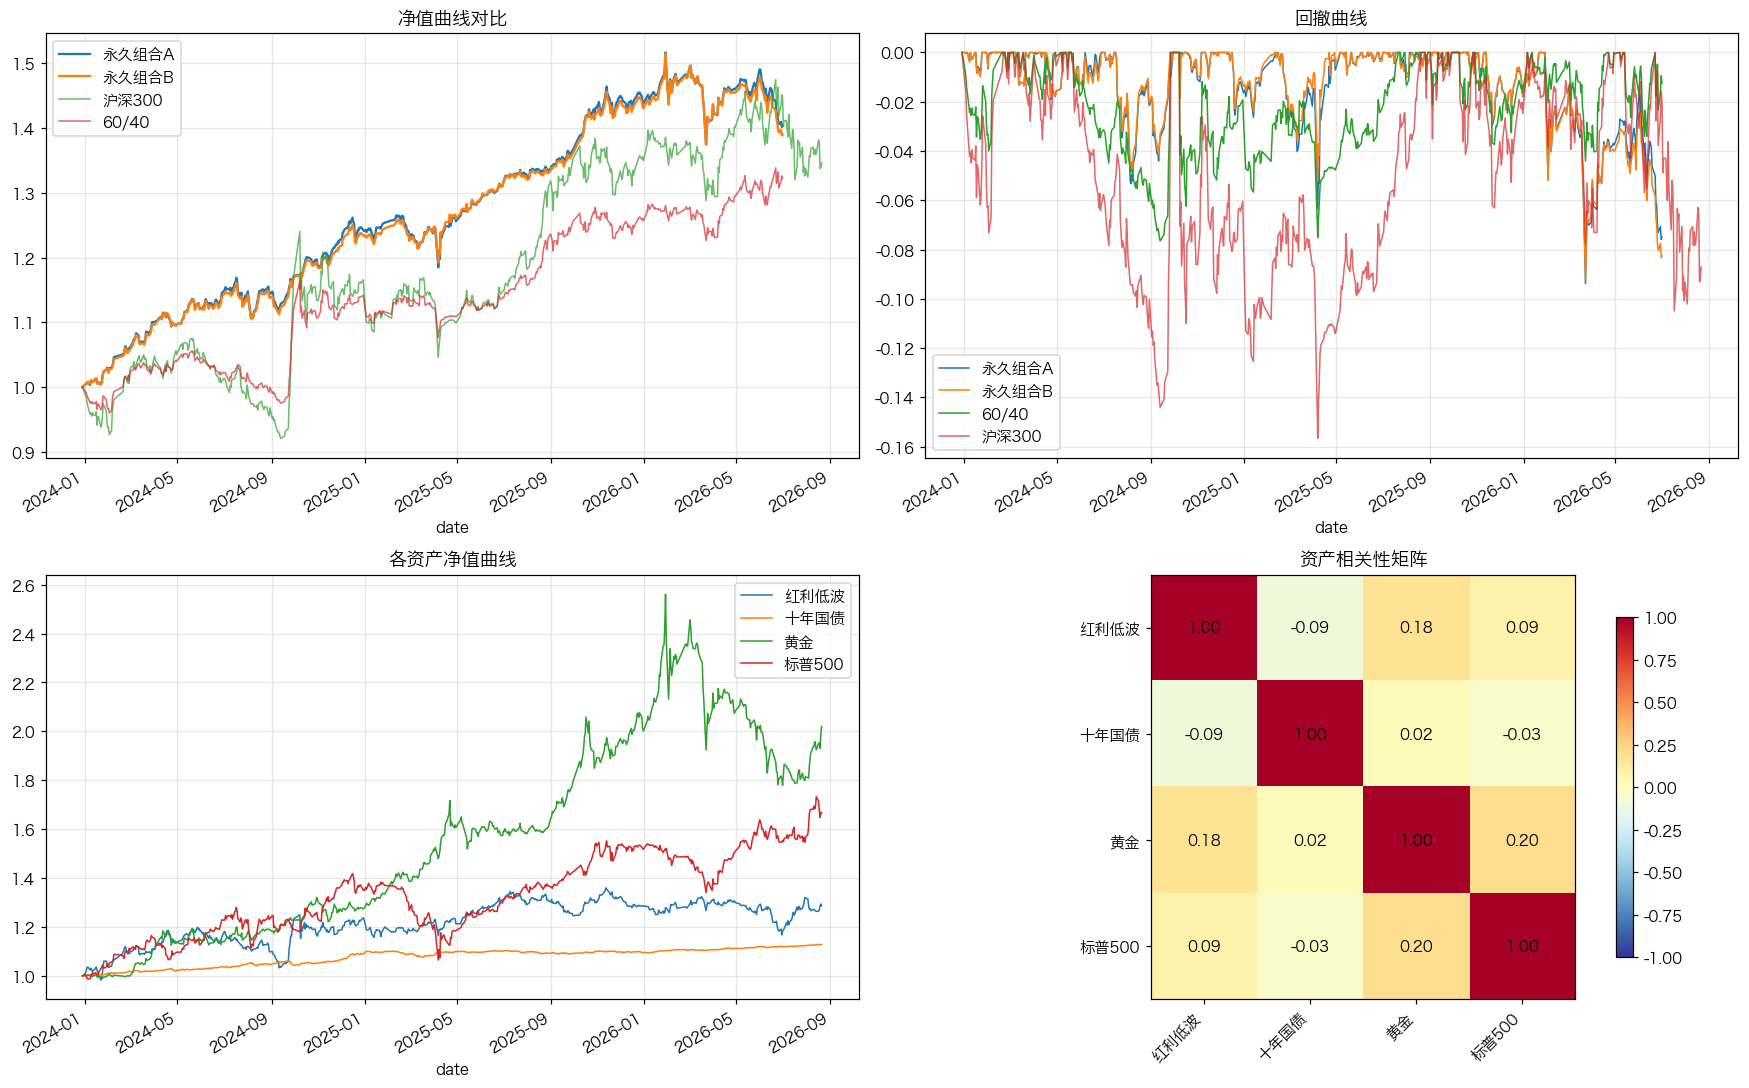

Chart saved to reports/generated/permanent_portfolio_cn.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
bt_a.daily_nav.plot(ax=ax, label='永久组合A', linewidth=1.5)
bt_b.daily_nav.plot(ax=ax, label='永久组合B', linewidth=1.5)
if bench_300_nav is not None:
    bench_300_nav.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
bt_6040.daily_nav.plot(ax=ax, label='60/40', linewidth=1, alpha=0.7)
ax.set_title('净值曲线对比')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
for nav_s, label in [(bt_a.daily_nav, '永久组合A'), (bt_b.daily_nav, '永久组合B'),
                      (bt_6040.daily_nav, '60/40')]:
    dd = nav_s / nav_s.expanding().max() - 1
    dd.plot(ax=ax, label=label, linewidth=1)
if bench_300_nav is not None:
    dd300 = bench_300_nav / bench_300_nav.expanding().max() - 1
    dd300.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
ax.set_title('回撤曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
for code in ['512890', '511260', '518880', '513500']:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        nav_i = df['close'] / df['close'].iloc[0]
        nav_i.plot(ax=ax, label=ALL_CODES.get(code, code), linewidth=1)
ax.set_title('各资产净值曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 1]
ret_df = pd.DataFrame()
for code in ['512890', '511260', '518880', '513500']:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        ret_df[ALL_CODES.get(code, code)] = df['close'].pct_change()
ret_df = ret_df.dropna()
corr = ret_df.corr()
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('资产相关性矩阵')
fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
os.makedirs('reports/generated', exist_ok=True)
plt.savefig('reports/generated/permanent_portfolio_cn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to reports/generated/permanent_portfolio_cn.png')

## 7. 季度头寸

In [9]:
pos_a = bt_a.quarterly_pos.copy()
pos_a.index = pos_a.index.strftime('%Y-%m-%d')
print('=== 版本 A: 无 QDII 限制 - 季度头寸（万元） ===')
print((pos_a / 10000).round(2).to_string())

print('\n=== 版本 B: QDII 30% 硬顶 - 季度头寸（万元） ===')
pos_b = bt_b.quarterly_pos.copy()
pos_b.index = pos_b.index.strftime('%Y-%m-%d')
print((pos_b / 10000).round(2).to_string())

=== 版本 A: 无 QDII 限制 - 季度头寸（万元） ===
            512890  511260  518880  513500
date                                      
2023-12-29   25.00   25.00   20.00   30.00
2024-01-02   25.13   25.13   20.10   30.15
2024-04-01   27.50   27.50   22.00   33.00
2024-07-01   28.72   28.72   22.98   34.46
2024-10-08   29.34   29.34   23.47   35.21
2025-01-02   31.07   31.07   24.85   37.28
2025-04-01   31.13   31.13   24.91   37.36
2025-07-01   32.91   32.91   26.33   39.49
2025-10-09   34.72   34.72   27.77   41.66
2026-01-05   36.23   36.23   28.98   43.48
2026-04-01   35.90   35.90   28.72   43.08
2026-07-01   35.08   35.08   28.06   42.09

=== 版本 B: QDII 30% 硬顶 - 季度头寸（万元） ===
            512890  511260  518880  513500
date                                      
2023-12-29   26.79   26.79   21.43   25.00
2024-01-02   26.92   26.92   21.54   25.13
2024-04-01   29.37   29.37   23.49   27.41
2024-07-01   30.62   30.62   24.50   28.58
2024-10-08   31.42   31.42   25.13   29.32
2025-01-02   33.05   33.

## 8. 月度收益

In [10]:
def monthly_returns(nav):
    ret = nav.pct_change().dropna()
    ret.index = pd.to_datetime(ret.index)
    monthly = ret.resample('M').apply(lambda x: (1+x).prod()-1)
    table = pd.DataFrame({
        'year': monthly.index.year,
        'month': monthly.index.month,
        'return': monthly.values
    })
    pivot = table.pivot(index='year', columns='month', values='return')
    pivot.columns = [f'{m}月' for m in pivot.columns]
    return pivot

print('=== 永久组合A 月度收益 ===')
mr_a = monthly_returns(bt_a.daily_nav)
print((mr_a * 100).round(2).to_string())

print('\n=== 永久组合B 月度收益 ===')
mr_b = monthly_returns(bt_b.daily_nav)
print((mr_b * 100).round(2).to_string())

if bench_300_nav is not None:
    print('\n=== 沪深300 月度收益 ===')
    mr_300 = monthly_returns(bench_300_nav)
    print((mr_300 * 100).round(2).to_string())

=== 永久组合A 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月   12月
year                                                                        
2024  2.77  3.26  3.71 -0.29  2.24  2.07 -0.38  0.25  2.44  1.60  3.07  1.15
2025  1.02 -1.95  0.67  1.50  2.34  2.00  1.35  0.42  2.40  4.71  0.98 -0.50
2026  3.75 -0.65 -4.60  3.29  0.99 -4.96  0.11   NaN   NaN   NaN   NaN   NaN

=== 永久组合B 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月   12月
year                                                                        
2024  2.65  3.07  3.64  0.07  2.21  1.59 -0.33  0.16  2.87  1.38  2.61  1.31
2025  0.98 -1.56  1.13  1.64  2.12  1.79  1.11  0.47  2.28  4.51  1.03 -0.44
2026  4.00 -0.55 -4.28  2.71  0.63 -5.12  0.09   NaN   NaN   NaN   NaN   NaN

=== 沪深300 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月     8月     9月   10月   11月   12月
year                                                                          
2024 -6.29  9